In [1]:
import numpy as np
import pickle
import pandas as pd
from loguru import logger
import matplotlib.pyplot as plt


In [4]:
test_flows = pd.read_csv('../interm/unsw_nb15_processed_test.csv')

In [5]:
len(test_flows)

448587

In [5]:
metrics_dir = '../interm/xAI/GNNE_20260305_183454/experiment.pkl'
with open(metrics_dir, 'rb') as f:
	explainability_report = pickle.load(f)

In [16]:
explainability_report.keys()

dict_keys(['epochs', 'window', 'learning_rate', 'description', 'metrics_per_window', 'window_number', 'average_mask_loss_curves', 'average_reg_loss_curves', 'mal_flows_in_window'])

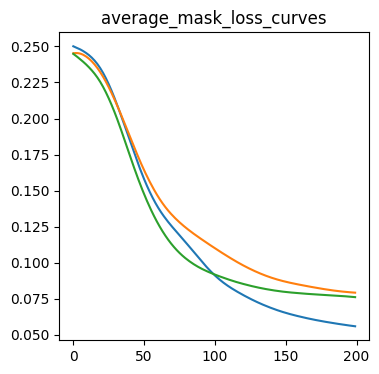

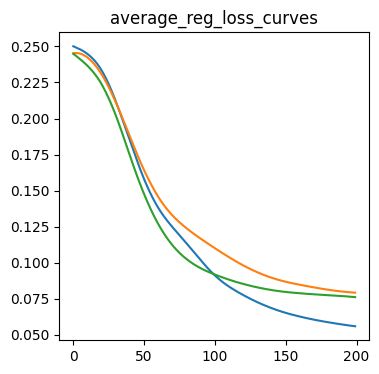

In [6]:
plt.figure(figsize=(4,4))

for curve in explainability_report['average_reg_loss_curves']:
	plt.plot(curve)
	plt.title('average_mask_loss_curves')
plt.show()

plt.figure(figsize=(4,4))
for curve in explainability_report['average_reg_loss_curves']:
	plt.plot(curve)
	plt.title('average_reg_loss_curves')
plt.show()

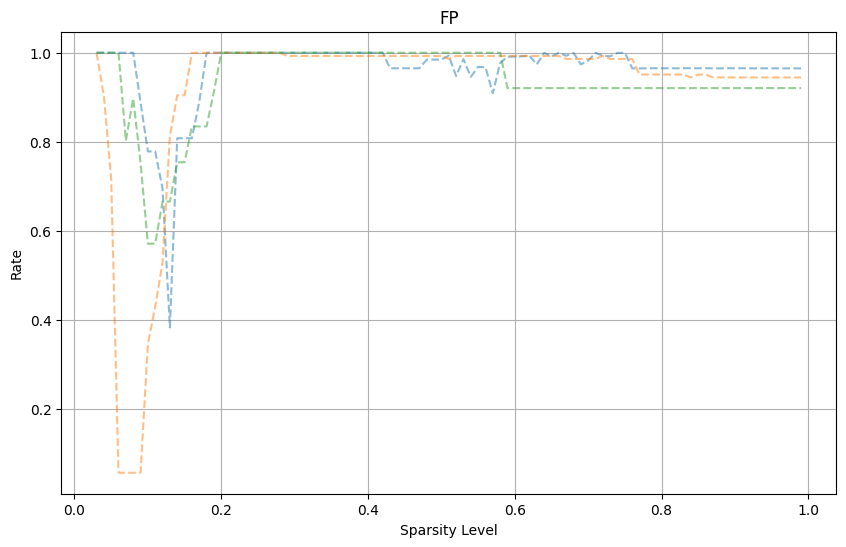

In [9]:
windows_metrics = explainability_report['metrics_per_window']

# for each windows, plot a line graph for fn and fp (y) for each sparisity level (x), 
# have all window plots on the same graph, with a small line thickness ans transperancy
plt.figure(figsize=(10, 6))
for i, metrics in enumerate(windows_metrics):
	sparsities, fidelities = zip(*metrics.items())
	y = np.array([f['fp'] for f in fidelities])[3:]
	x = np.array(sparsities)[3:]
	plt.plot(x, y, label=f'Window {i+1} FP', linestyle='--', alpha=0.5, )

plt.xlabel('Sparsity Level')
plt.ylabel('Rate')
plt.title('FP')
plt.grid()
plt.show()

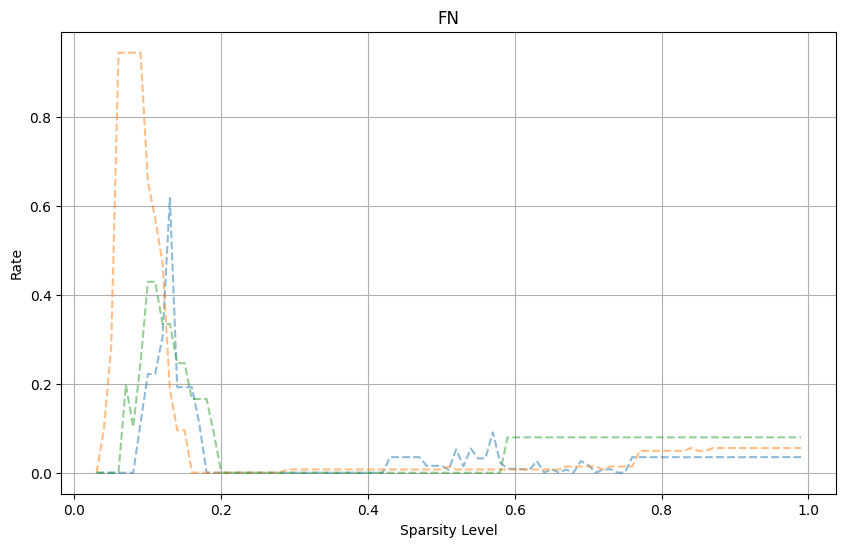

In [8]:
windows_metrics = explainability_report['metrics_per_window']

# for each windows, plot a line graph for fn and fp (y) for each sparisity level (x), 
# have all window plots on the same graph, with a small line thickness ans transperancy
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
for i, metrics in enumerate(windows_metrics):
	sparsities, fidelities = zip(*metrics.items())
	y = np.array([f['fn'] for f in fidelities])[3:]
	x = np.array(sparsities)[3:]
	plt.plot(x, y, label=f'Window {i+1} FN', linestyle='--', alpha=0.5, )

plt.xlabel('Sparsity Level')
plt.ylabel('Rate')
plt.title('FN')
plt.grid()
plt.show()